In [115]:
import pickle
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import math


In [116]:
method = 'pearson'

In [117]:
from numpy import argmax


def read_object(filename: str, path : Path):
    if not (path / filename).is_file():
        return None
    return pickle.load(open(path / filename, 'rb'))

def plot_corr(path, method, data, scales, bases, title, name_exp):
    unique_scales = np.unique(scales)
    unique_bases = np.unique(bases)
    
    # Attribuer une couleur par base
    cmap = plt.get_cmap('tab10')  # ou 'viridis', 'Set1', etc.
    base_to_color = {base: cmap(i % 10) for i, base in enumerate(unique_bases)}

    n_col = 3
    n_row = math.ceil(len(unique_scales) / n_col)
    fig, axs = plt.subplots(n_row, n_col, figsize=(35, 25))
    axs = axs.flatten()
    
    maximum_values = []

    print(f'#################### Optimisze parameters #########################')

    for idx, scale in enumerate(unique_scales):
        mask = scales == scale
        arg_max = np.argmax(data[mask])
        
        print(f'{title} {scale} -> {name_exp[mask][arg_max]}')
        
        maximum_values.append(f'{title} {scale} -> {name_exp[mask][arg_max]}')

        ax = axs[idx]
        sum_scale = data[mask]
        base_scale = np.array(bases)[mask]

        x = np.arange(len(sum_scale))
        colors = [base_to_color[base] for base in base_scale]
        
        ax.bar(x, sum_scale, color=colors)
        ax.set_title(f"Scale: {scale}", fontsize=15)
        ax.set_xticks(x)
        ax.set_xticklabels(np.array(name_exp)[mask], rotation=90, ha='right', fontsize=15)  # facultatif
        ax.scatter(arg_max, sum_scale.iloc[arg_max], color='red')

    # Cacher les sous-graphiques inutilisés
    for k in range(idx + 1, len(axs)):
        axs[k].axis('off')

    # Légende (optionnelle)
    handles = [plt.Rectangle((0,0),1,1, color=base_to_color[b]) for b in unique_bases] + [plt.Circle((0,0), 1, color='red') for scale in scales]
    labels = [str(b) for b in unique_bases] + [maximum_values]

    fig.legend(handles, labels, title={title}, loc='lower right')

    plt.tight_layout()
    plt.title(f'{title}', fontsize=18)
    plt.show()
    plt.savefig(f'{path}/{title}_{method}.png')
    plt.close('all')


In [118]:
def analyse(path, name, method):
    df = read_object(f'{name}_{method}.pkl', path)
    features_name = list(df.columns)
    features_name = [col for col in features_name if col != 'name']
    name_exp = df['name'].values
    df.drop('name', inplace=True, axis=1)
    sum = df.sum(axis=1)
    df['name'] = name_exp
    name_exp[0]
    scales_lambda = lambda x : x.split('/')[1].split('_')[0][1]
    attempt_lambda = lambda x : x.split('/')[1].split('_')[1][1]
    reduce_lambda = lambda x : x.split('/')[1].split('_')[2][1]
    base_lambda = lambda x : x.split('/')[0]

    scales = np.asarray([scales_lambda(xi) for xi in name_exp], dtype=int)
    attempts = [attempt_lambda(xi) for xi in name_exp]
    reduces = [reduce_lambda(xi) for xi in name_exp]
    bases = [base_lambda(xi) for xi in name_exp]
    plot_corr(path, method, sum, scales, bases, 'base', name_exp)
    #plot_corr(sum, scales, attempts, 'Dildation', name_exp)
    #plot_corr(sum, scales, reduces, 'Reduce', name_exp)

#################### Optimisze parameters #########################
base 1 -> risk-size-watershed/s1_a2_r5
base 2 -> risk-size-watershed/s2_a4_r6
base 3 -> risk-size-watershed/s3_a1_r2
base 4 -> risk-size-watershed/s4_a2_r6
base 5 -> risk-size-watershed/s5_a5_r6
base 6 -> risk-size-watershed/s6_a2_r5
base 7 -> risk-size-watershed/s7_a5_r6


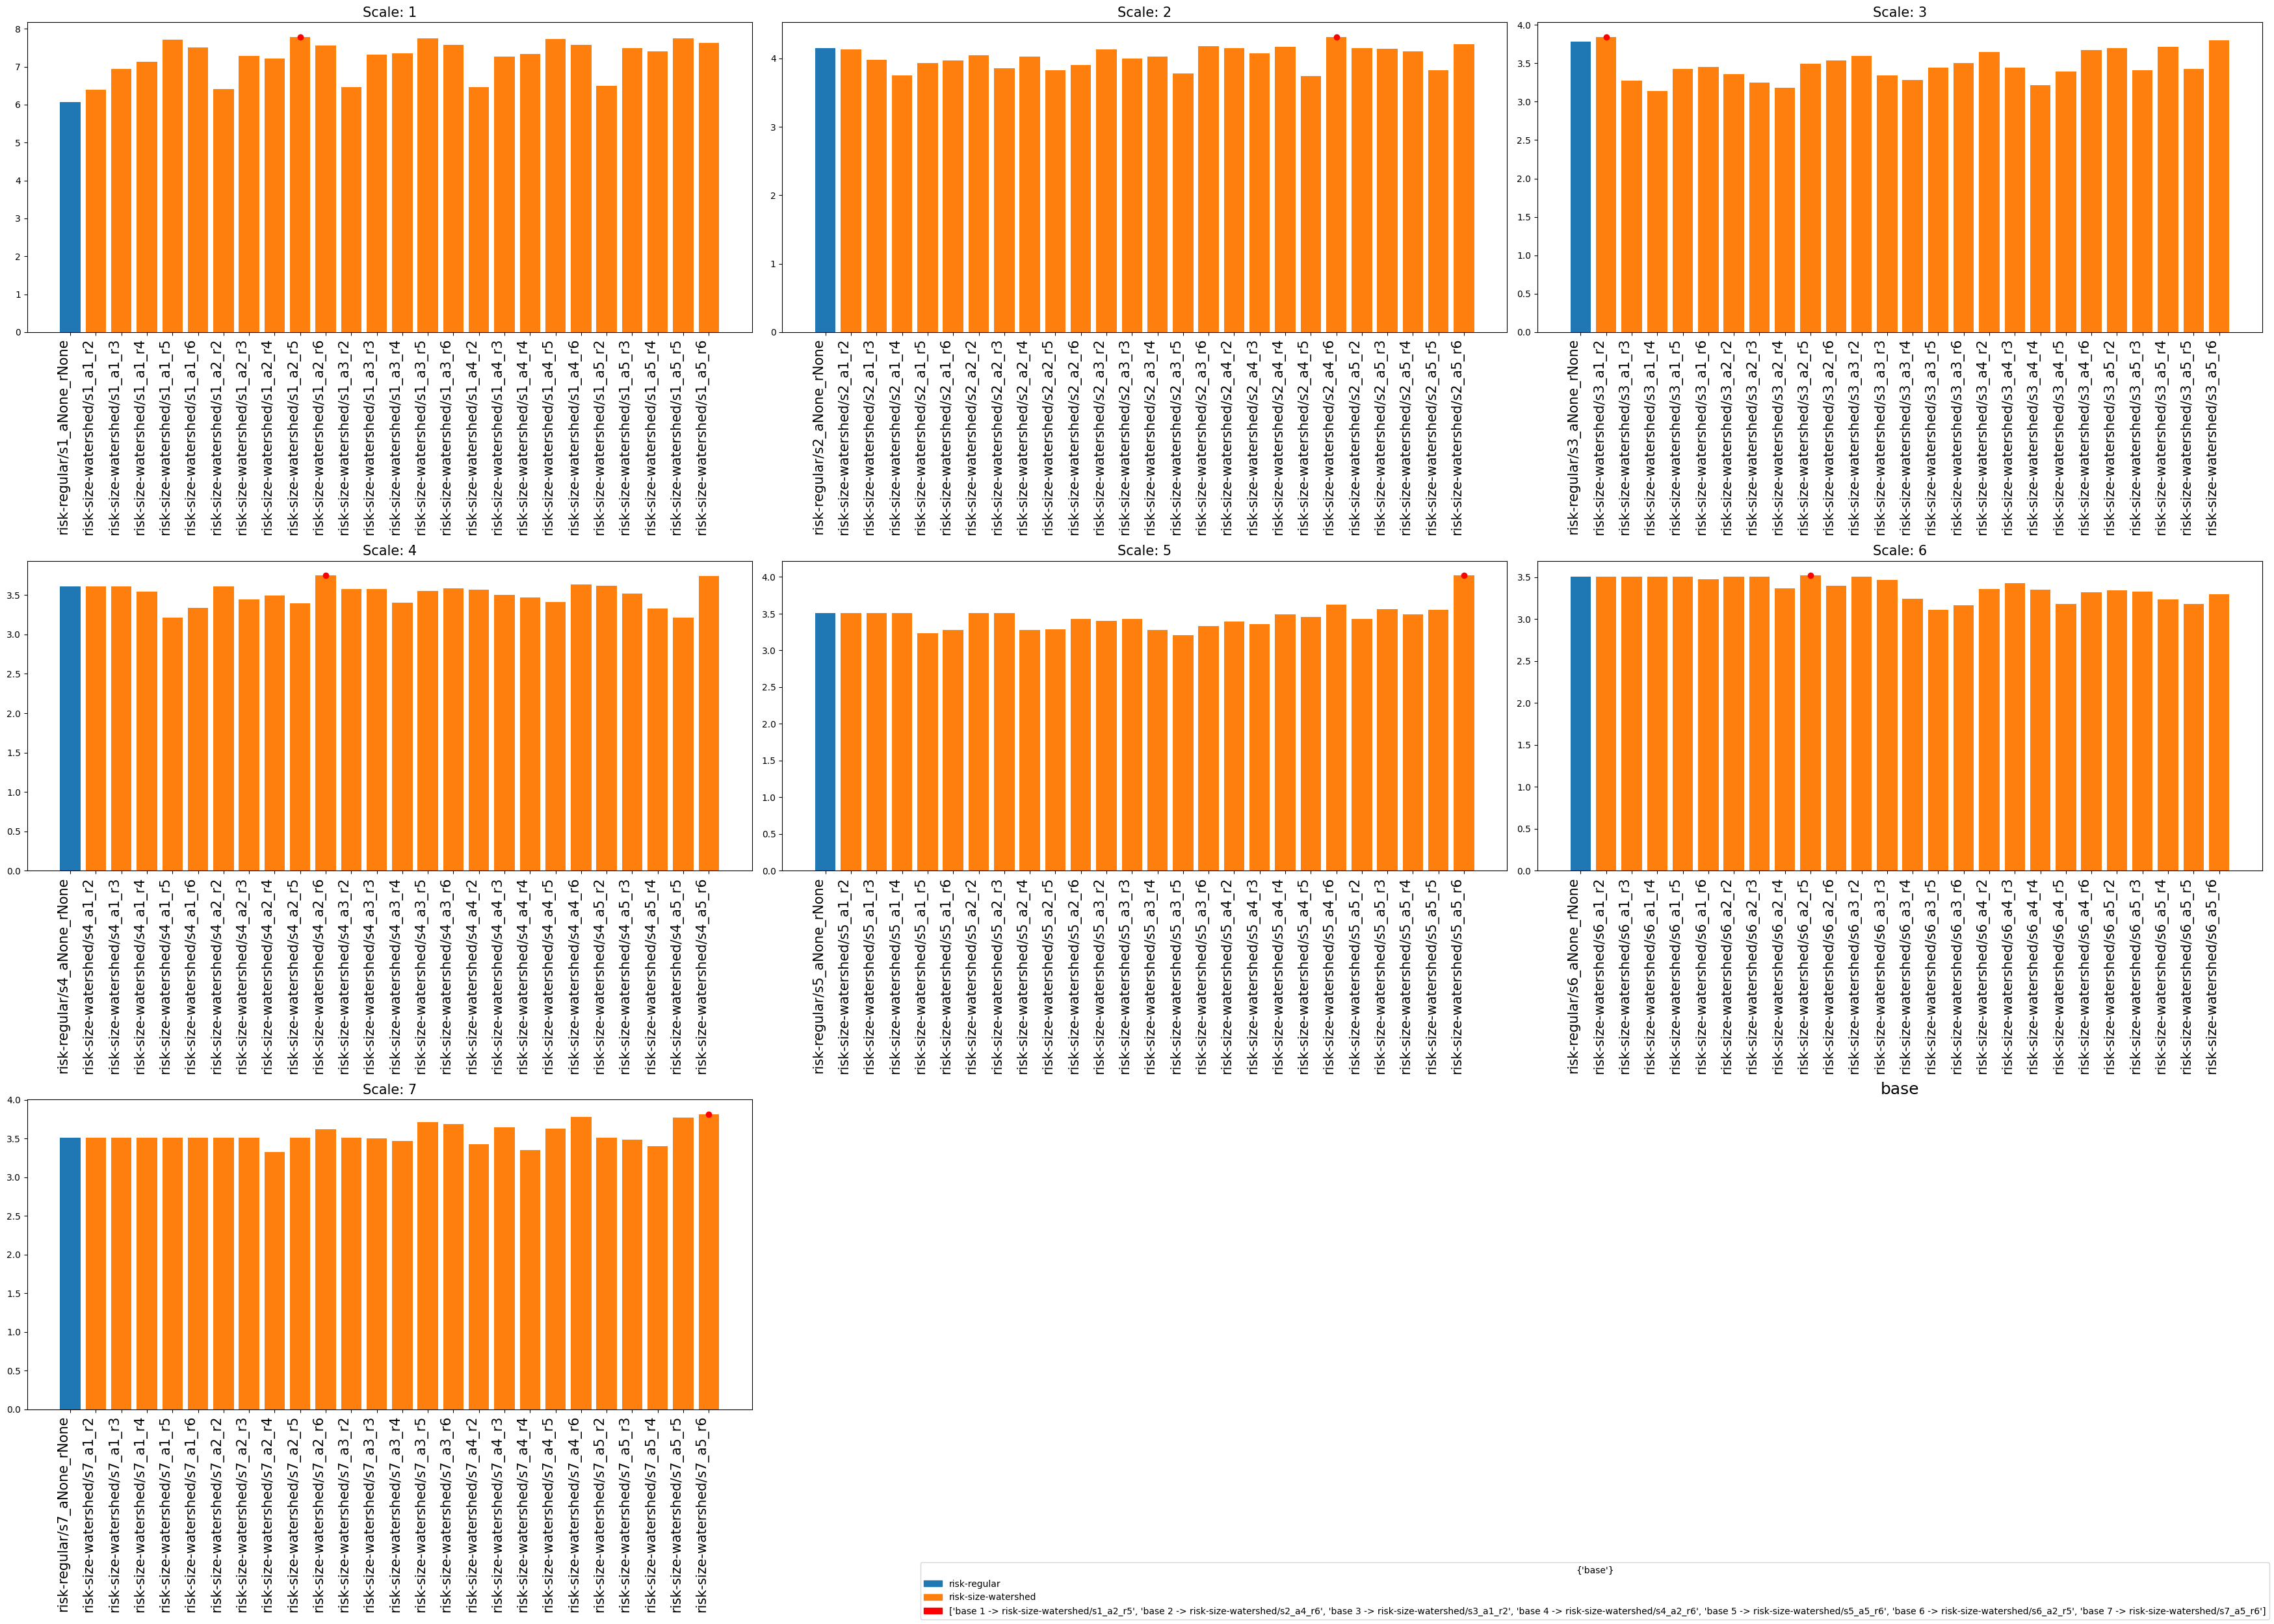

In [119]:
################# firemen ###################
file = Path('/media/caron/X9 Pro/travaille/Thèse/segmentation')
analyse(file, 'firemen', method)

#################### Optimisze parameters #########################
base 1 -> risk-size-watershed/s1_a3_r5
base 2 -> risk-size-watershed/s2_a3_r5
base 3 -> risk-size-watershed/s3_a4_r5
base 4 -> risk-size-watershed/s4_a5_r6
base 5 -> risk-size-watershed/s5_a4_r5
base 6 -> risk-regular/s6_aNone_rNone
base 7 -> risk-regular/s7_aNone_rNone


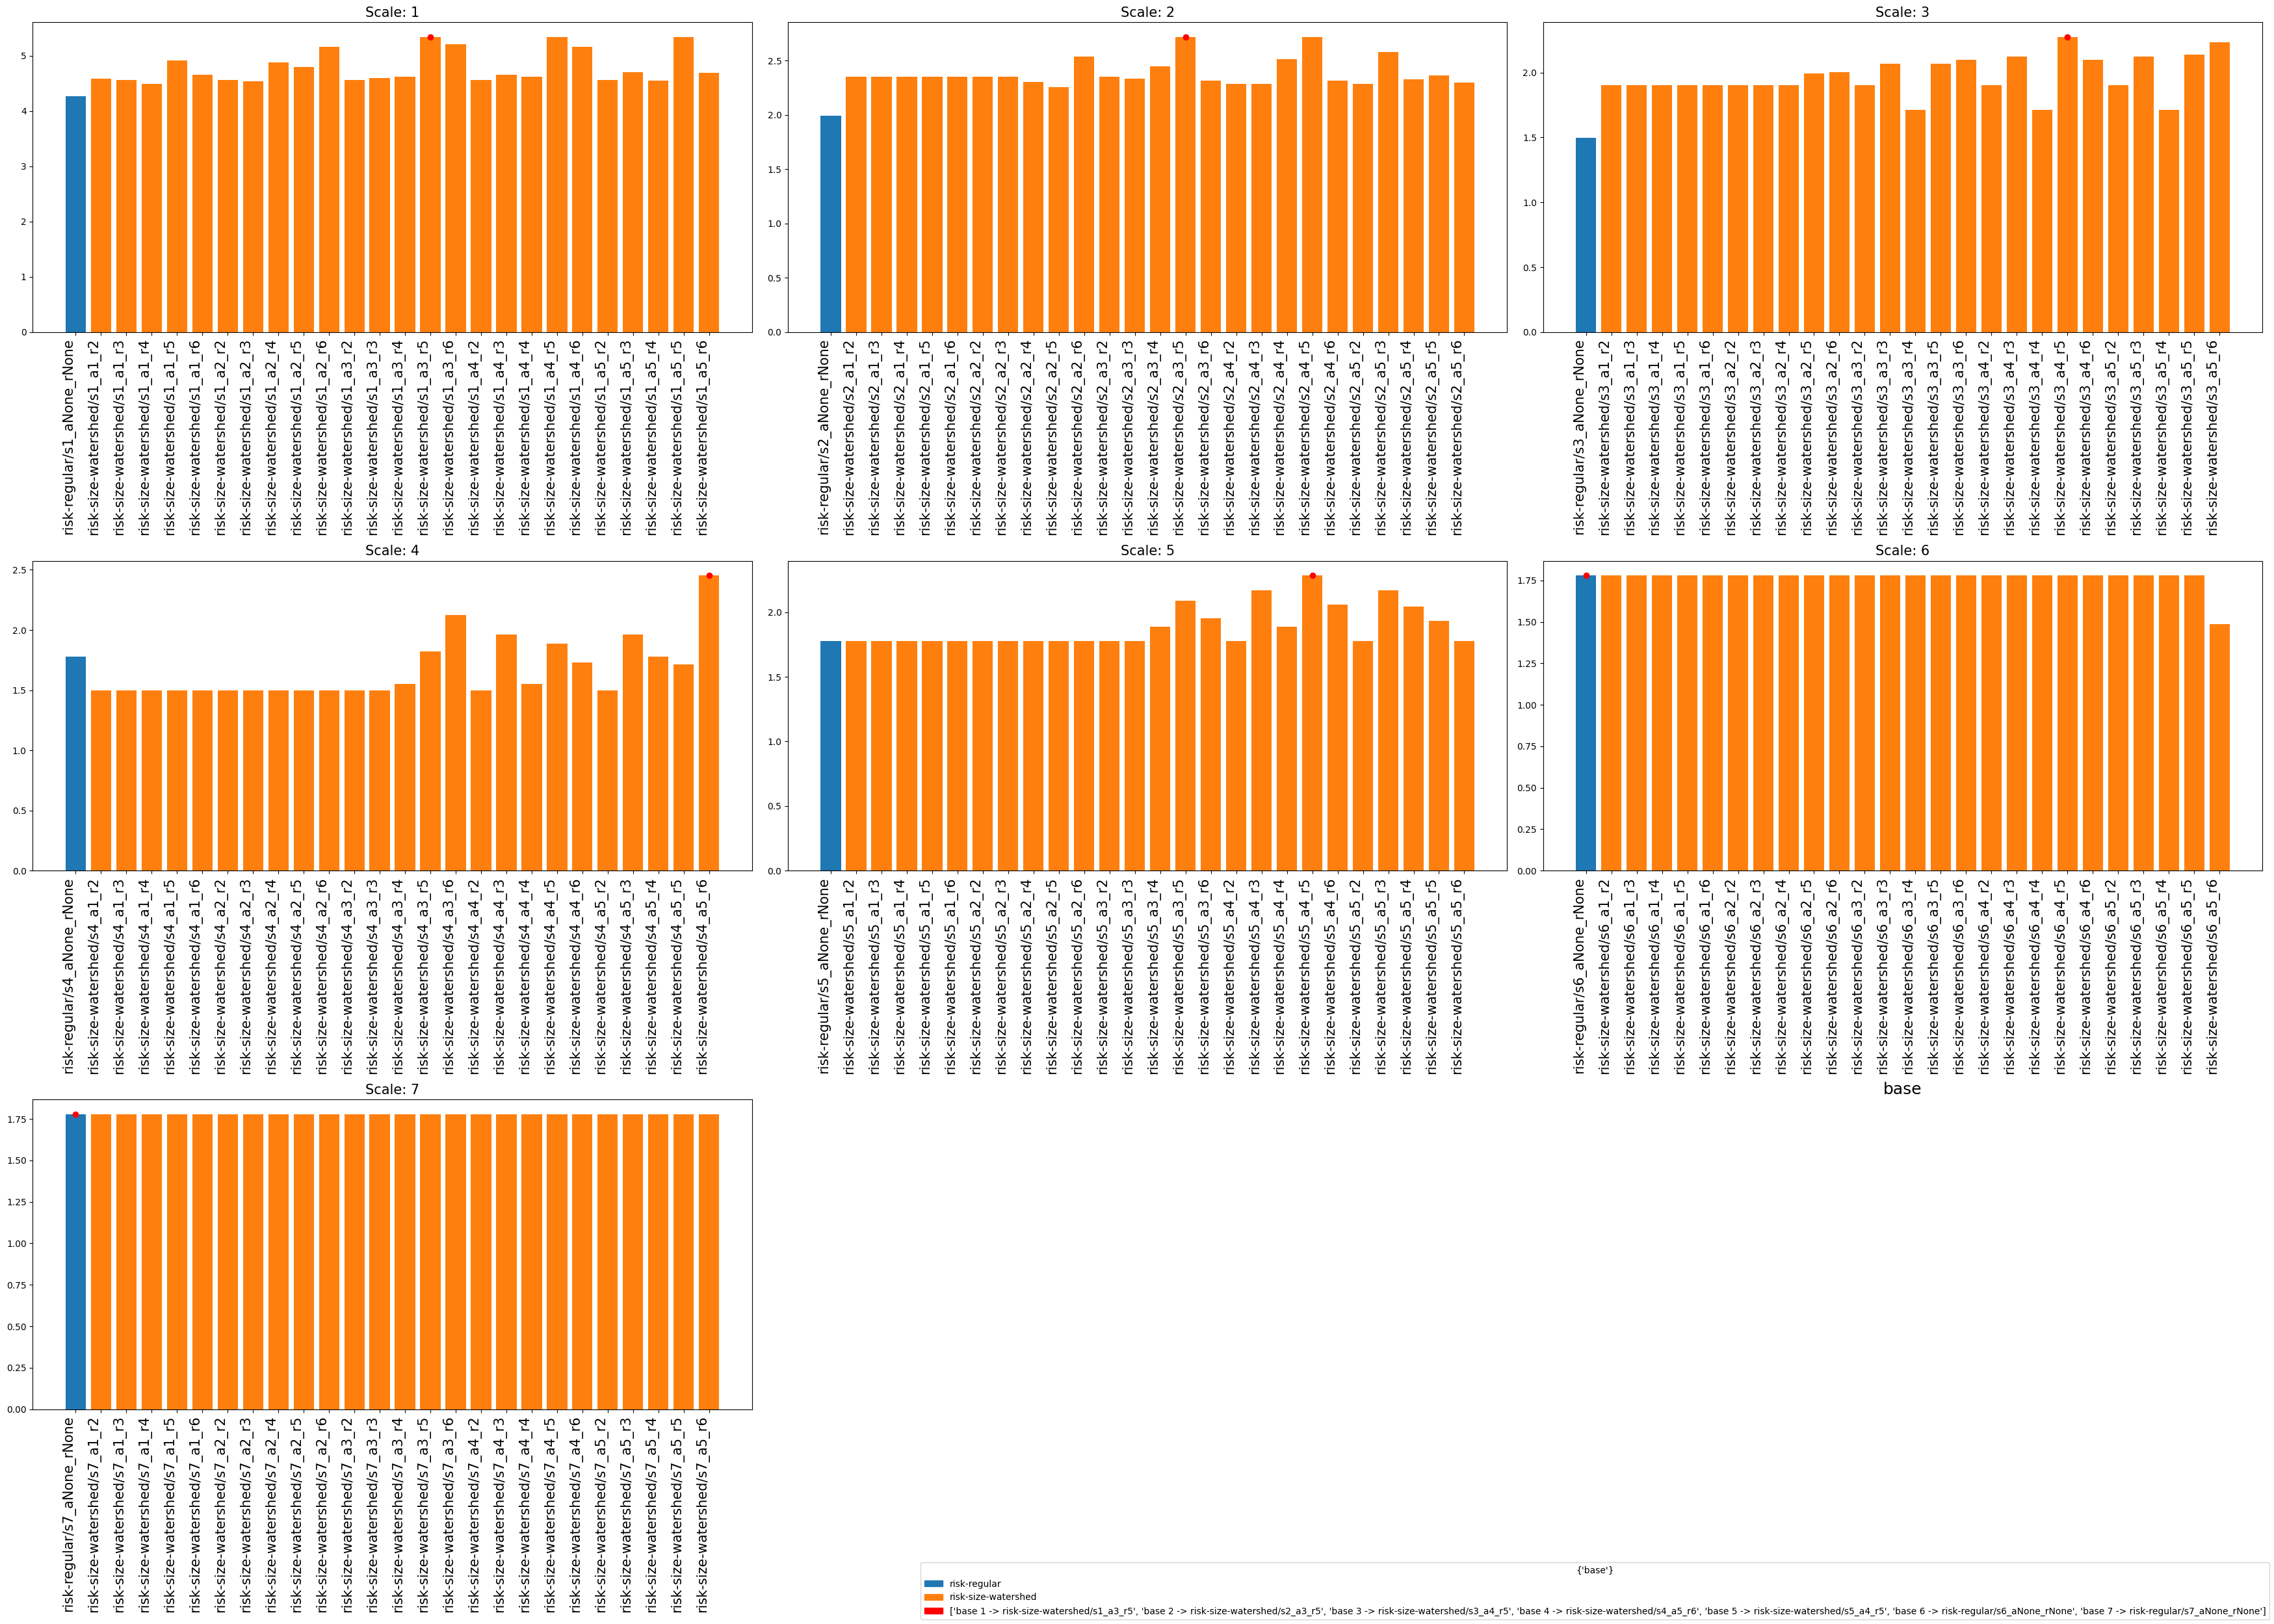

In [120]:
################# bdiff ###################
file = Path('/media/caron/X9 Pro/travaille/Thèse/segmentation')
analyse(file, 'bdiff_small', method)

#################### Optimisze parameters #########################
base 1 -> risk-size-watershed/s1_a2_r6
base 2 -> risk-size-watershed/s2_a5_r3
base 3 -> risk-size-watershed/s3_a4_r3
base 4 -> risk-size-watershed/s4_a3_r6
base 5 -> risk-size-watershed/s5_a5_r5
base 6 -> risk-size-watershed/s6_a2_r5
base 7 -> risk-size-watershed/s7_a4_r3


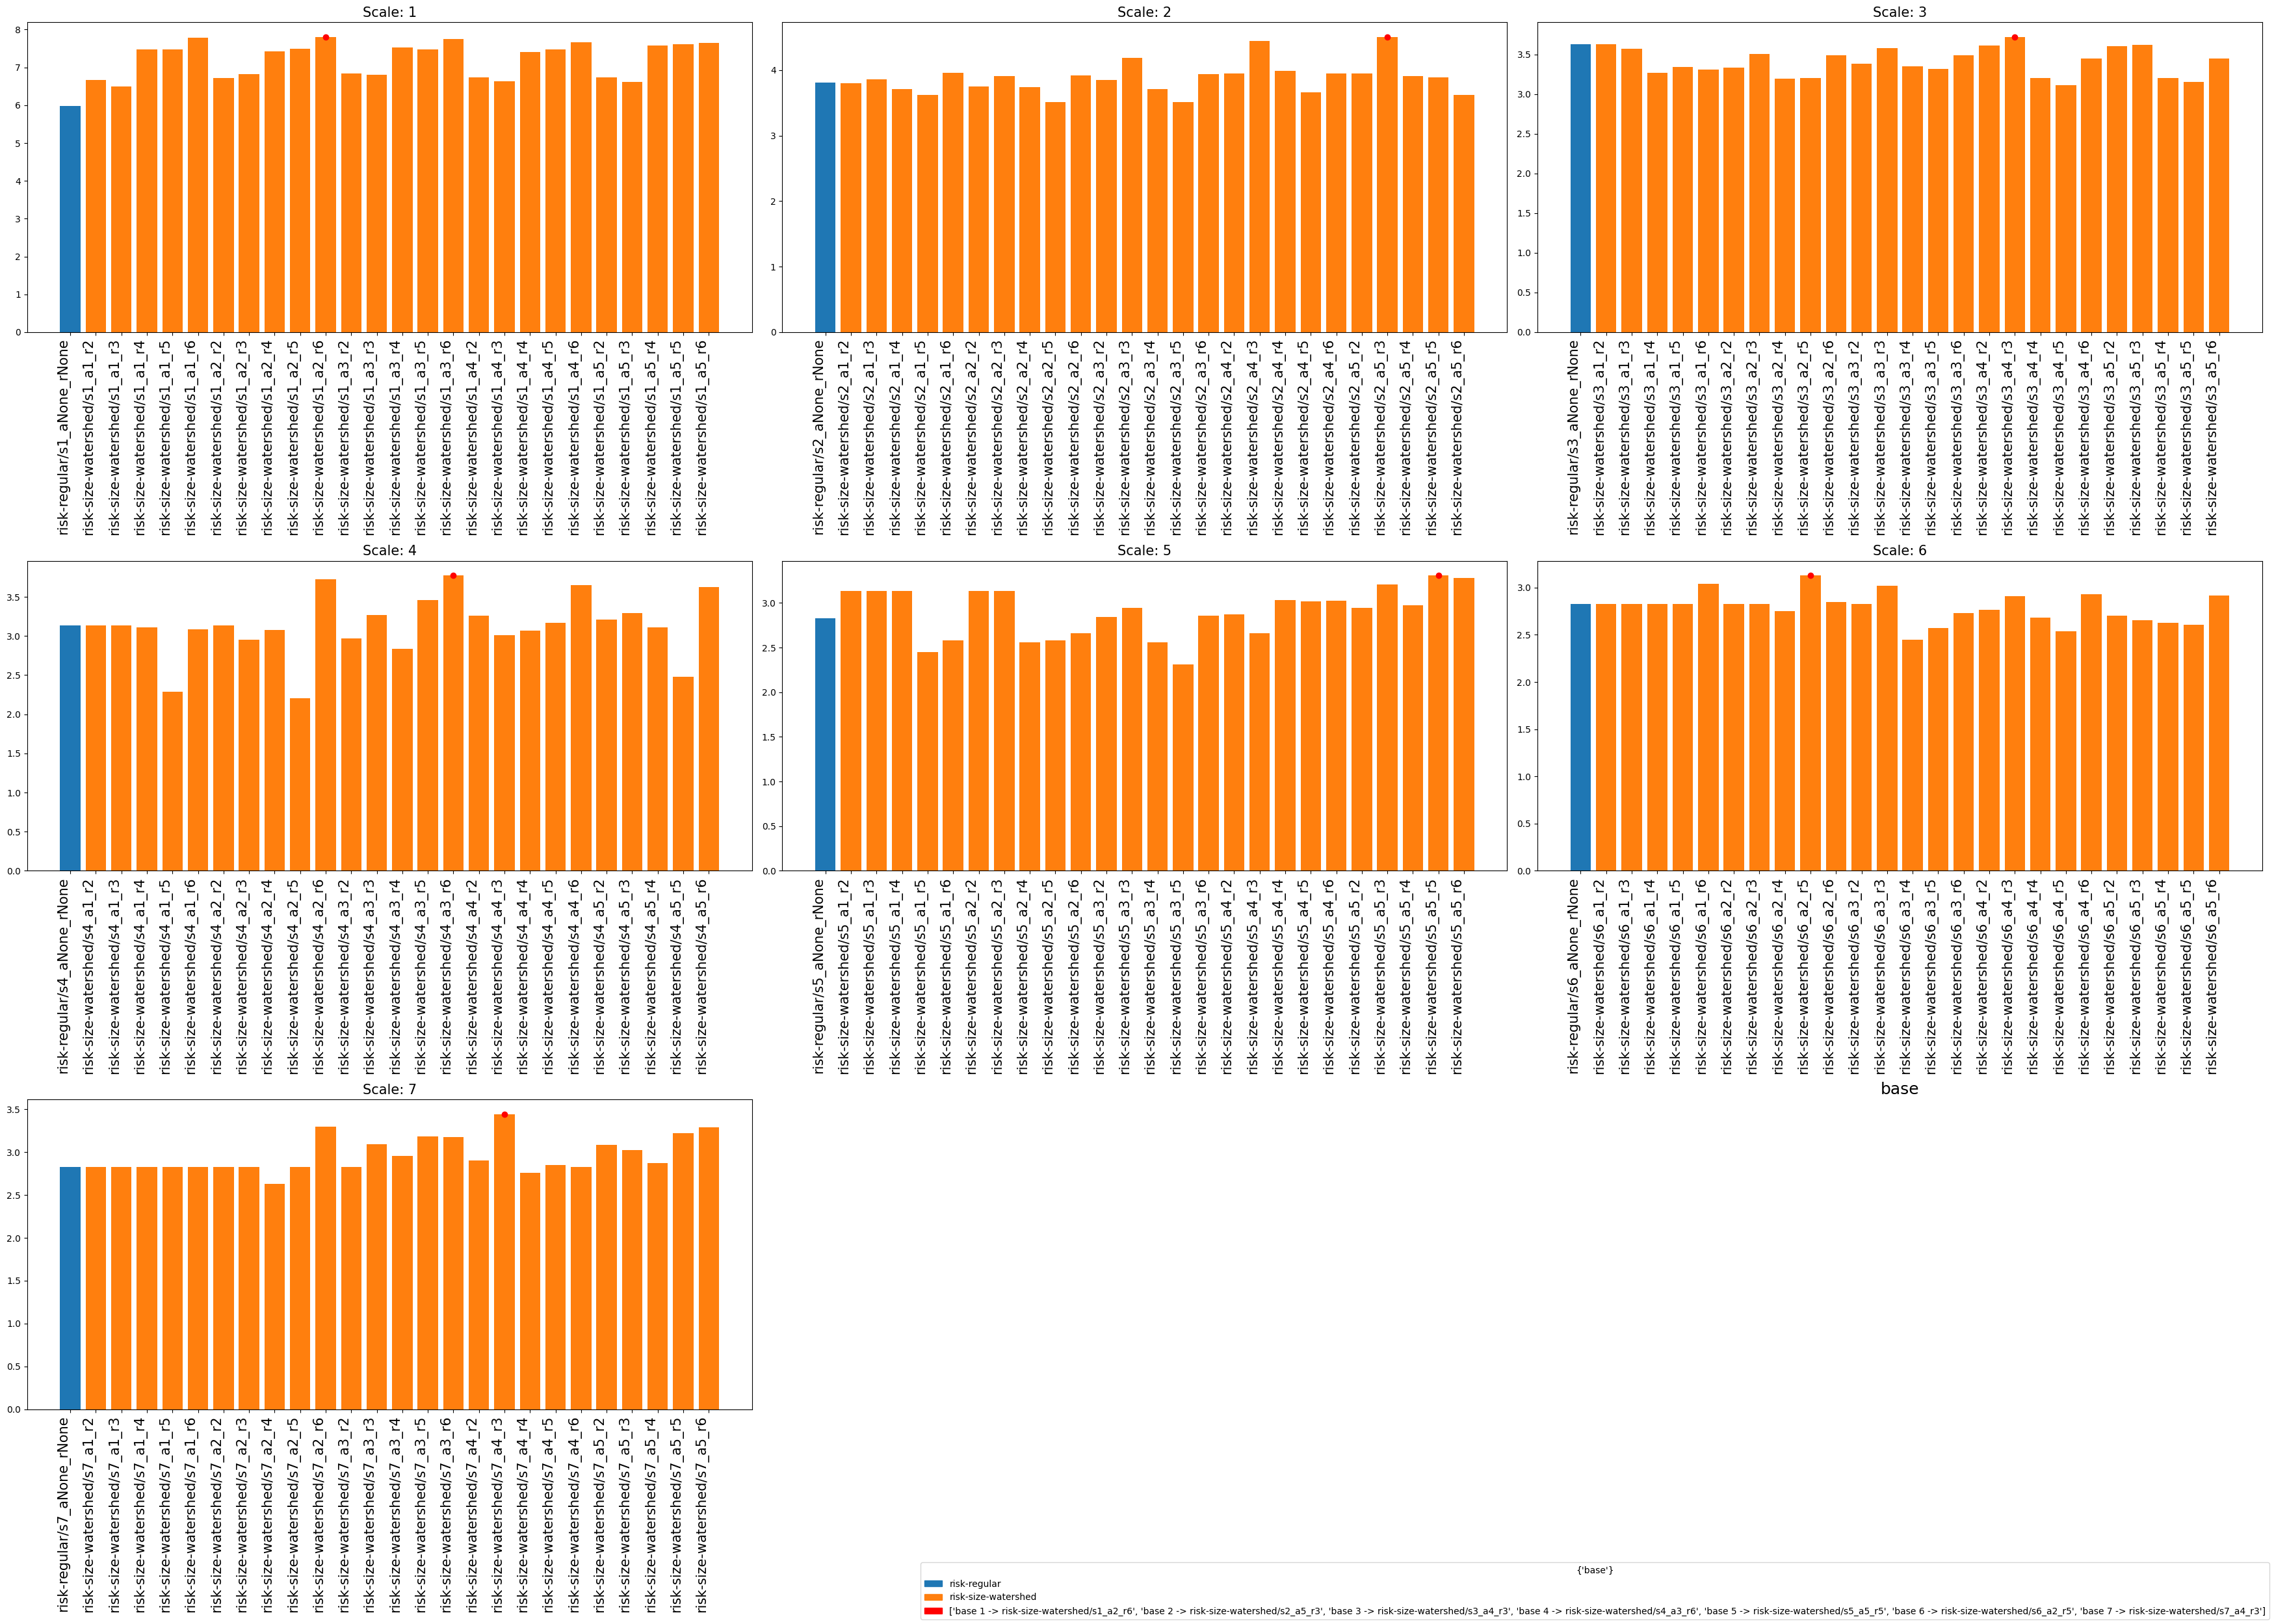

#################### Optimisze parameters #########################
base 1 -> risk-size-watershed/s1_a3_r5
base 2 -> risk-size-watershed/s2_a3_r5
base 3 -> risk-size-watershed/s3_a4_r5
base 4 -> risk-size-watershed/s4_a5_r6
base 5 -> risk-size-watershed/s5_a4_r5
base 6 -> risk-regular/s6_aNone_rNone
base 7 -> risk-regular/s7_aNone_rNone


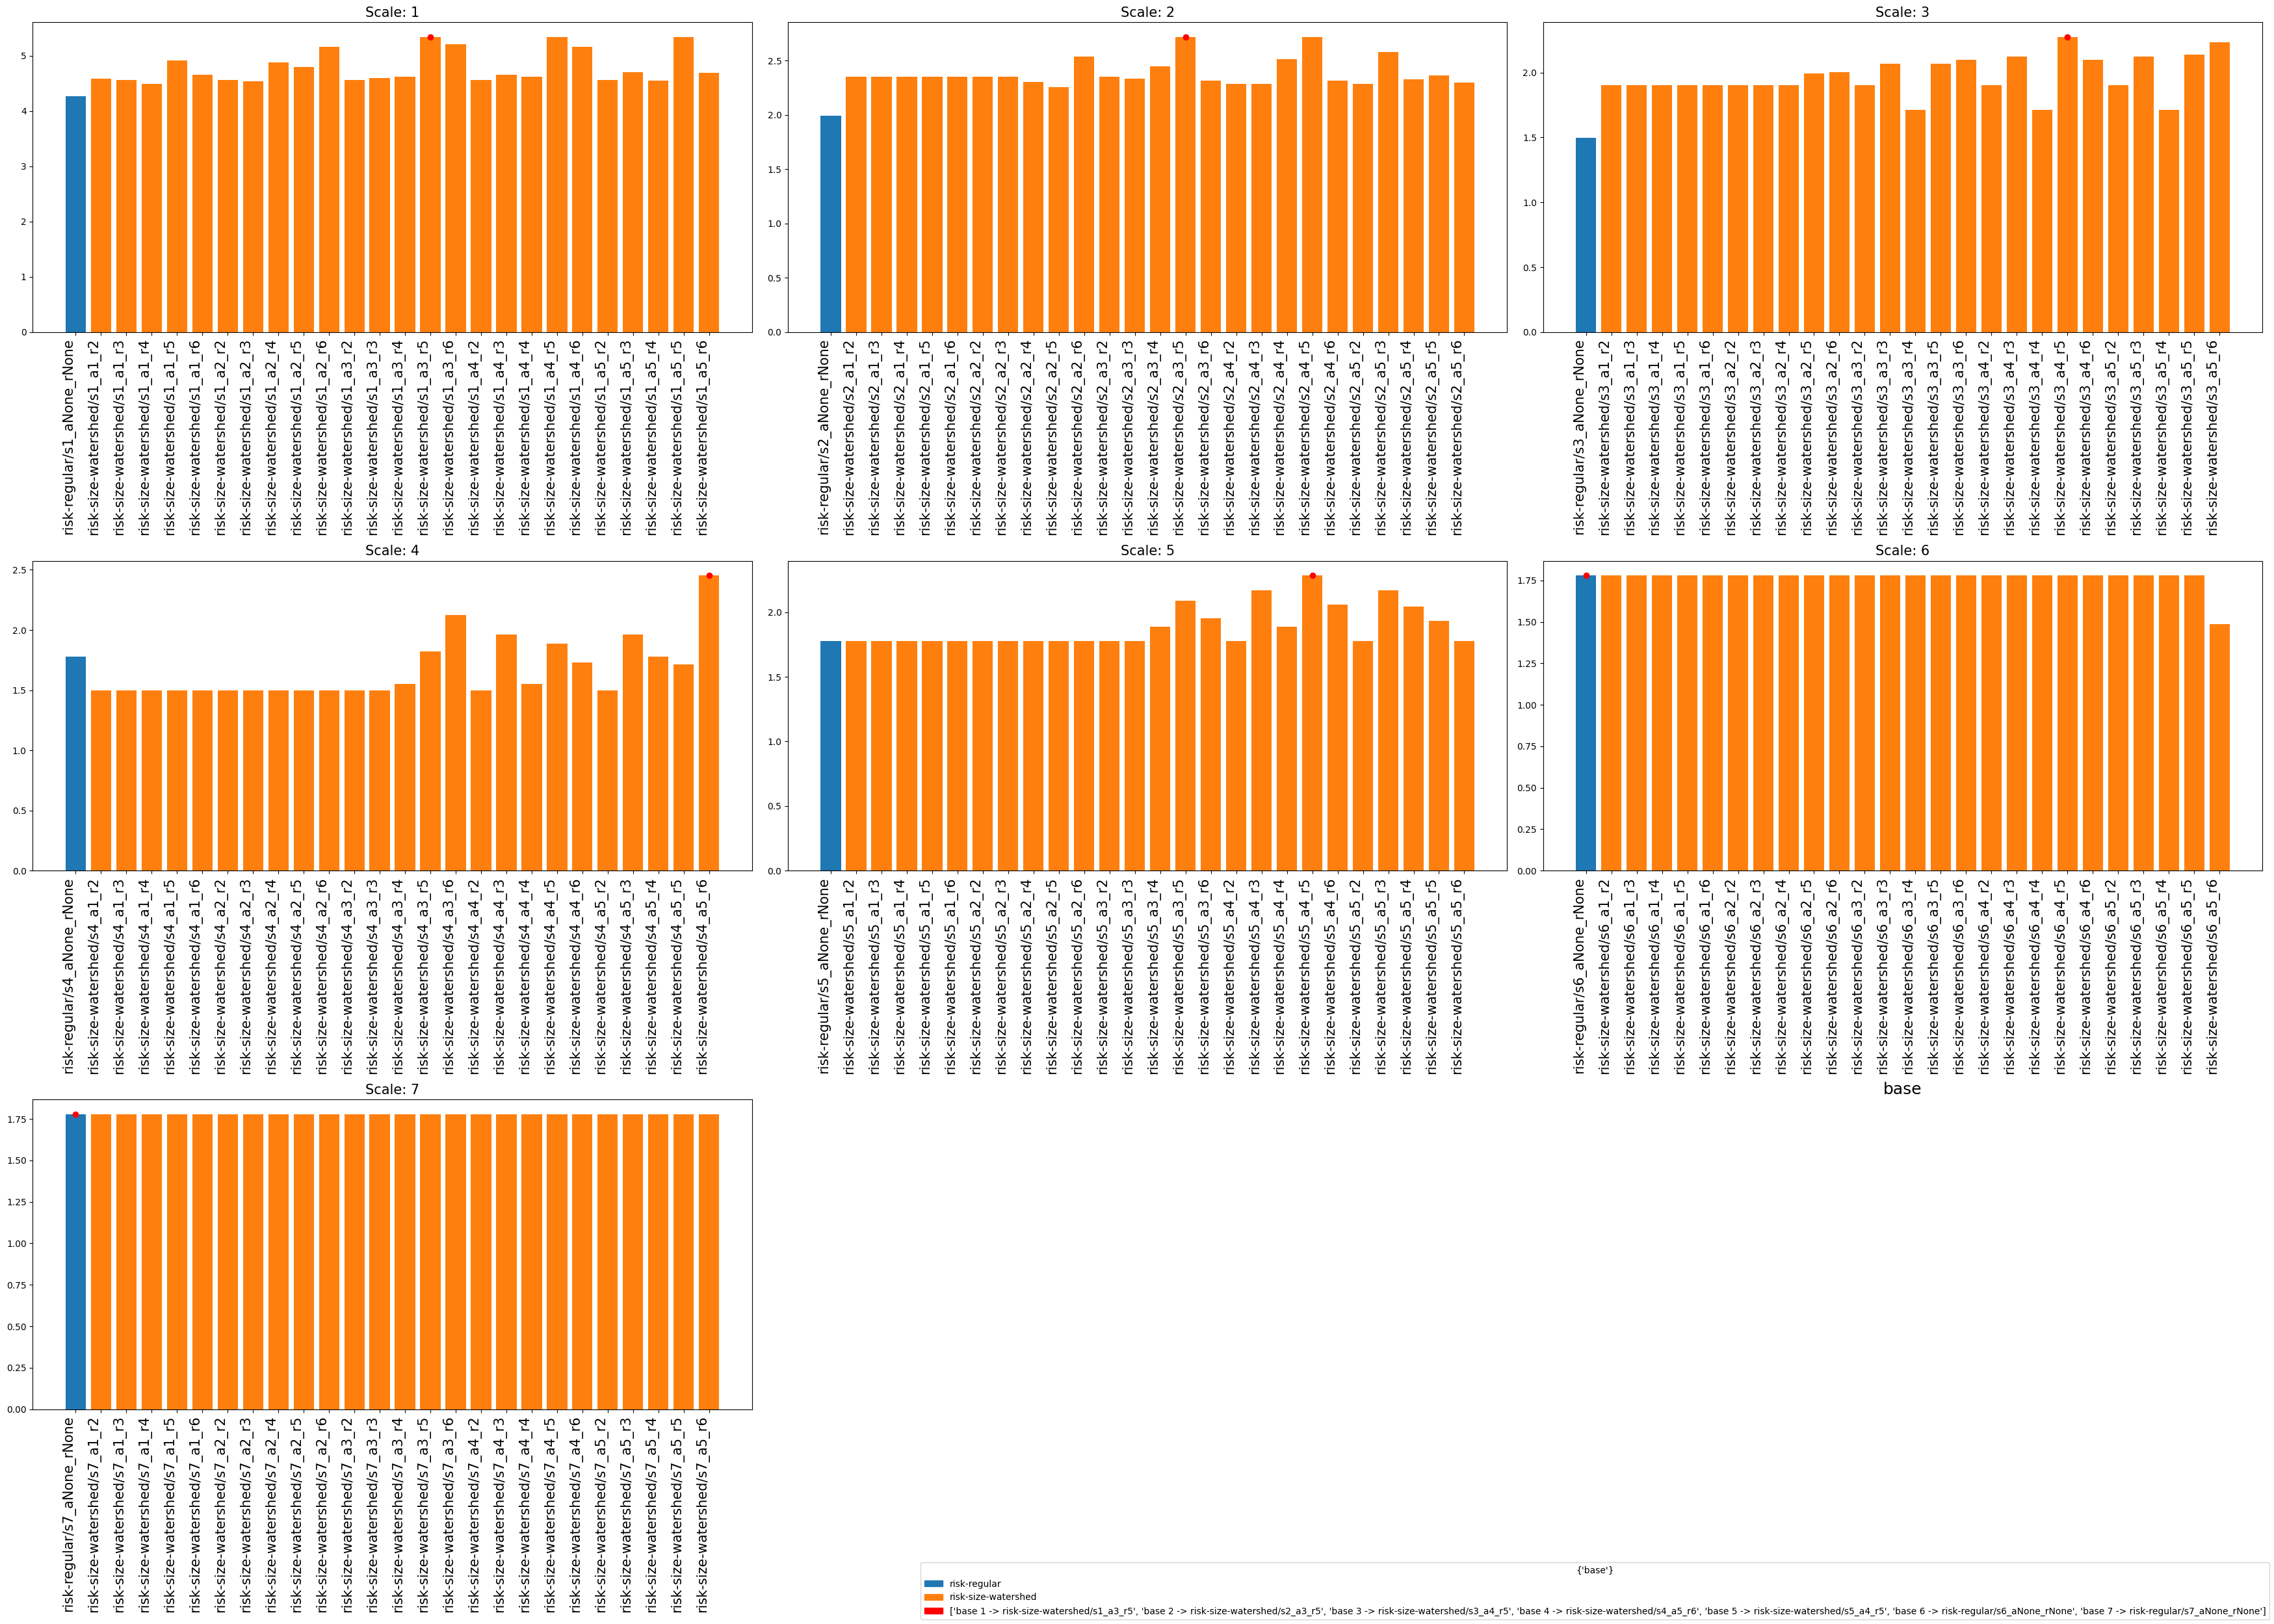

#################### Optimisze parameters #########################
base 1 -> risk-size-watershed/s1_a5_r3
base 2 -> risk-size-watershed/s2_a4_r6
base 3 -> risk-size-watershed/s3_a3_r4
base 4 -> risk-size-watershed/s4_a4_r4
base 5 -> risk-size-watershed/s5_a2_r6
base 6 -> risk-regular/s6_aNone_rNone
base 7 -> risk-size-watershed/s7_a4_r6


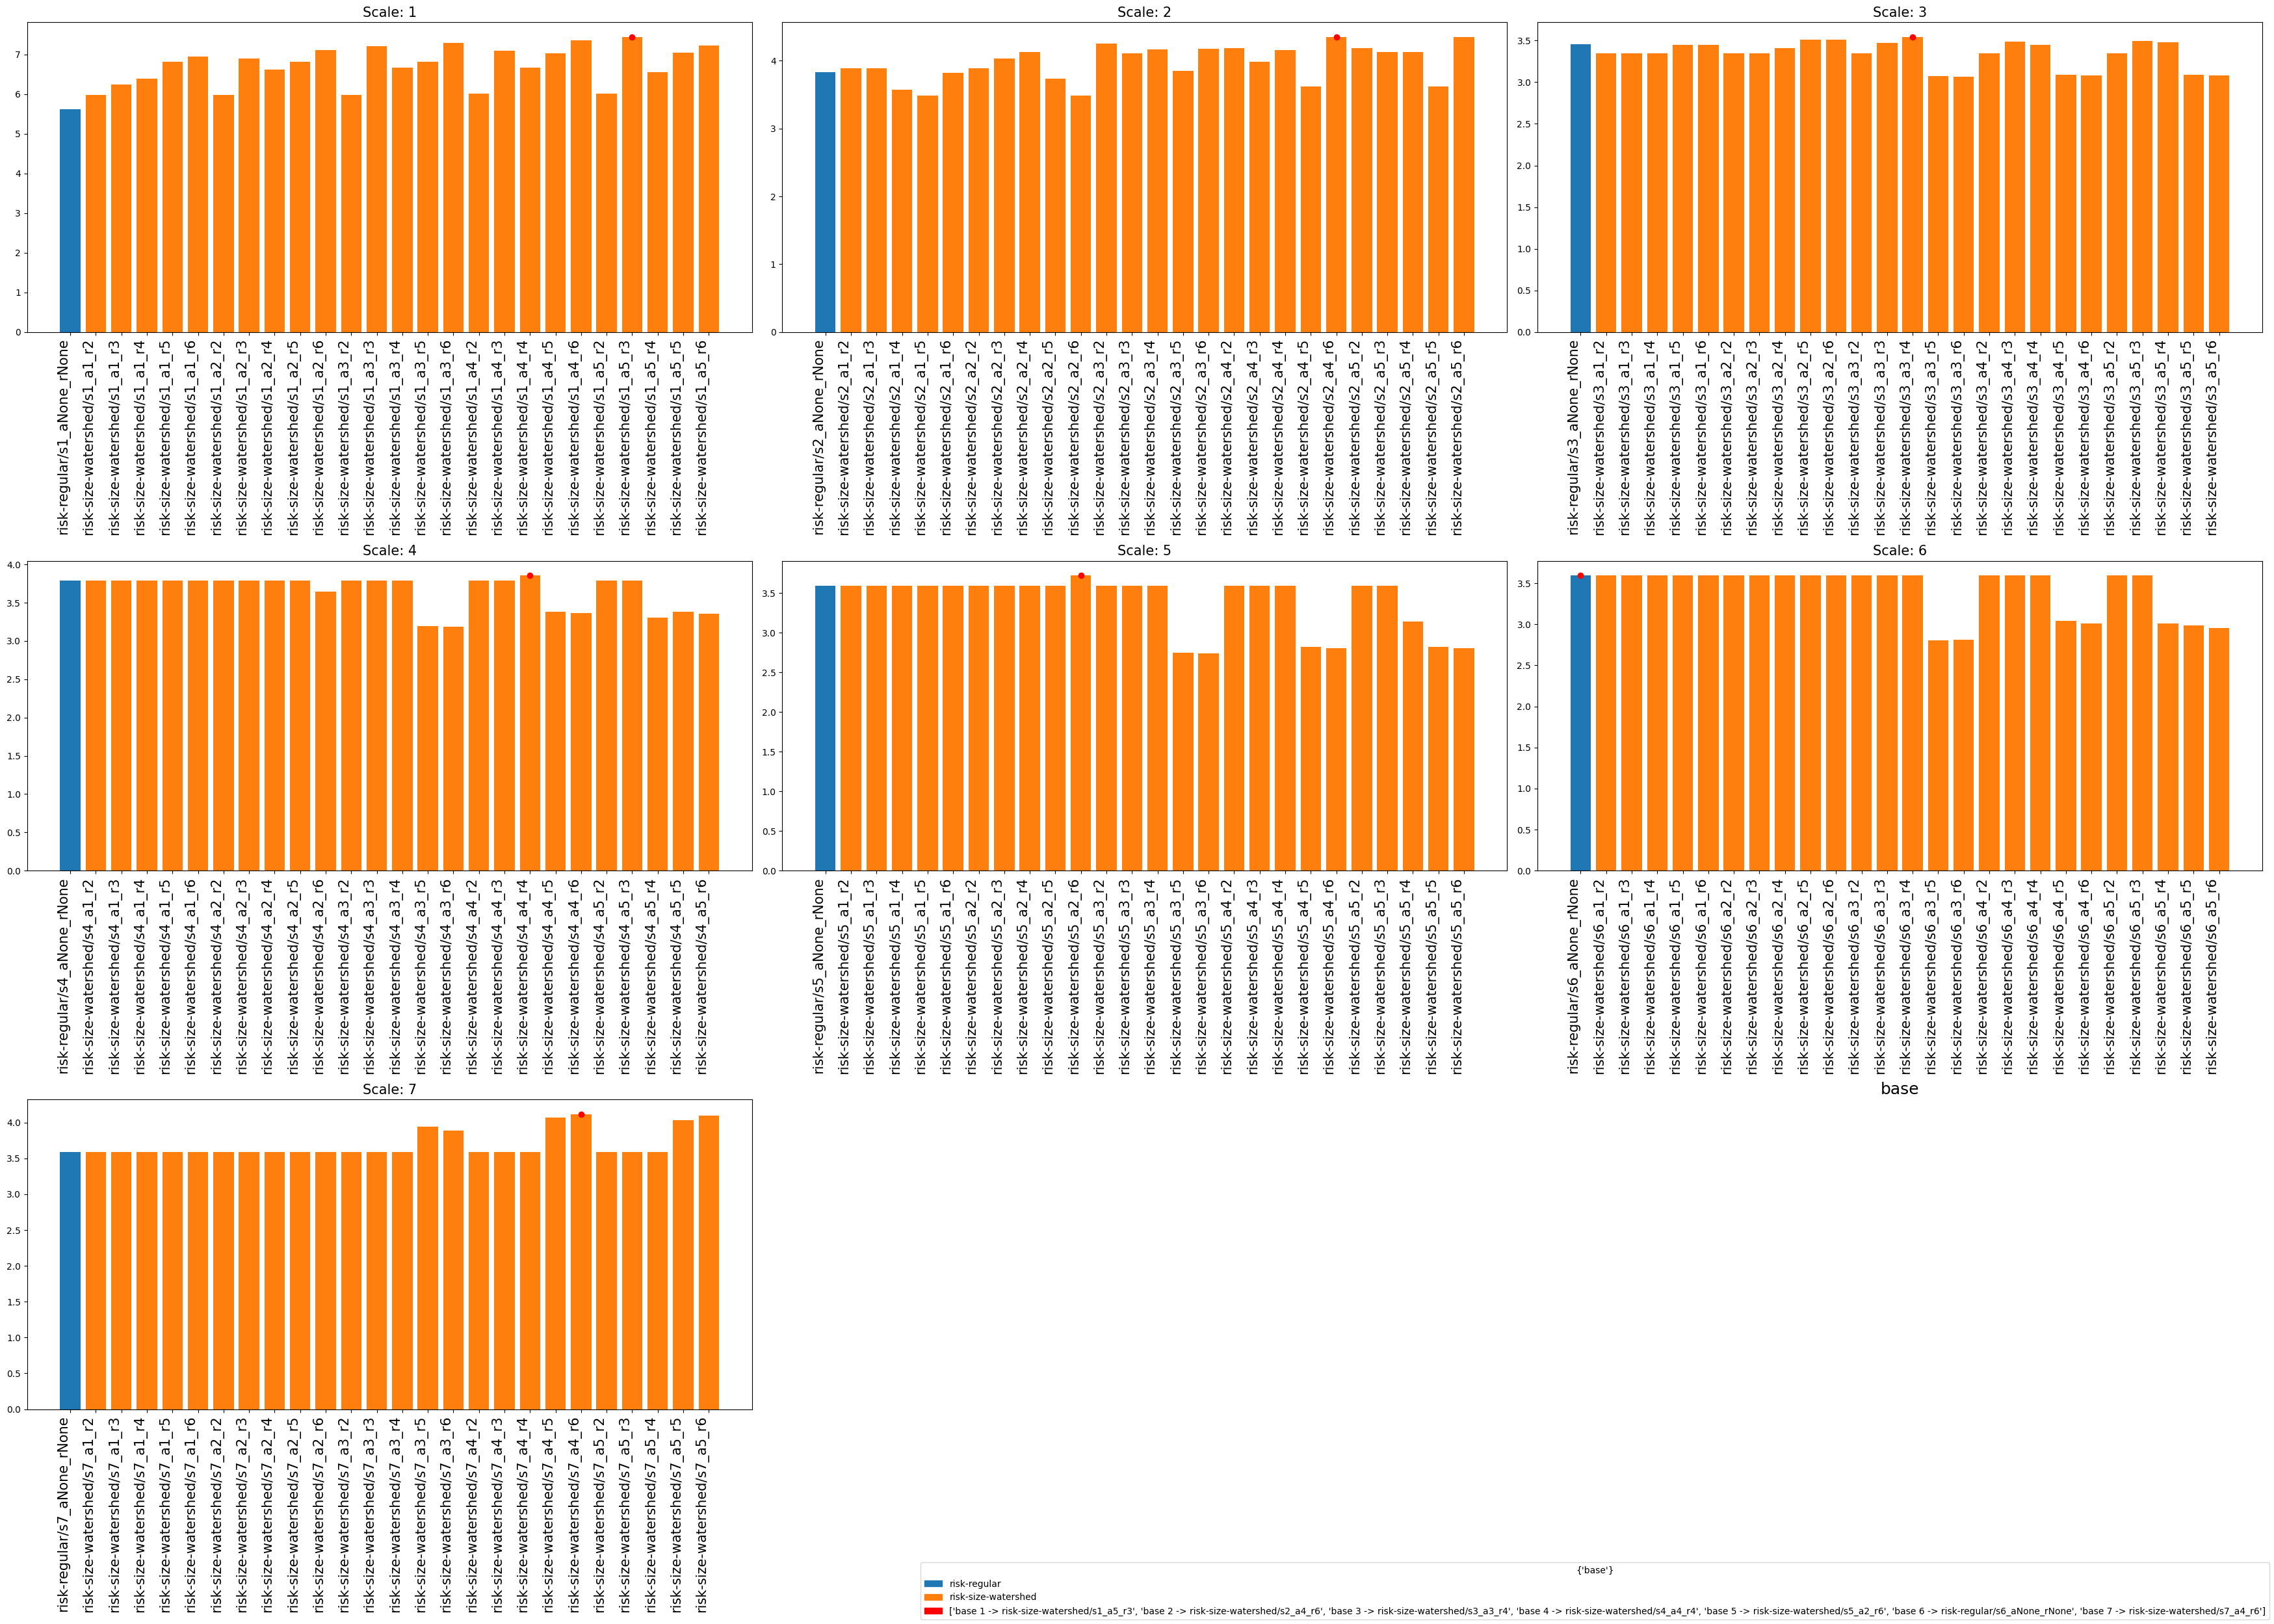

#################### Optimisze parameters #########################
base 1 -> risk-size-watershed/s1_a5_r3
base 2 -> risk-regular/s2_aNone_rNone
base 3 -> risk-regular/s3_aNone_rNone
base 4 -> risk-regular/s4_aNone_rNone
base 5 -> risk-regular/s5_aNone_rNone
base 6 -> risk-regular/s6_aNone_rNone
base 7 -> risk-regular/s7_aNone_rNone


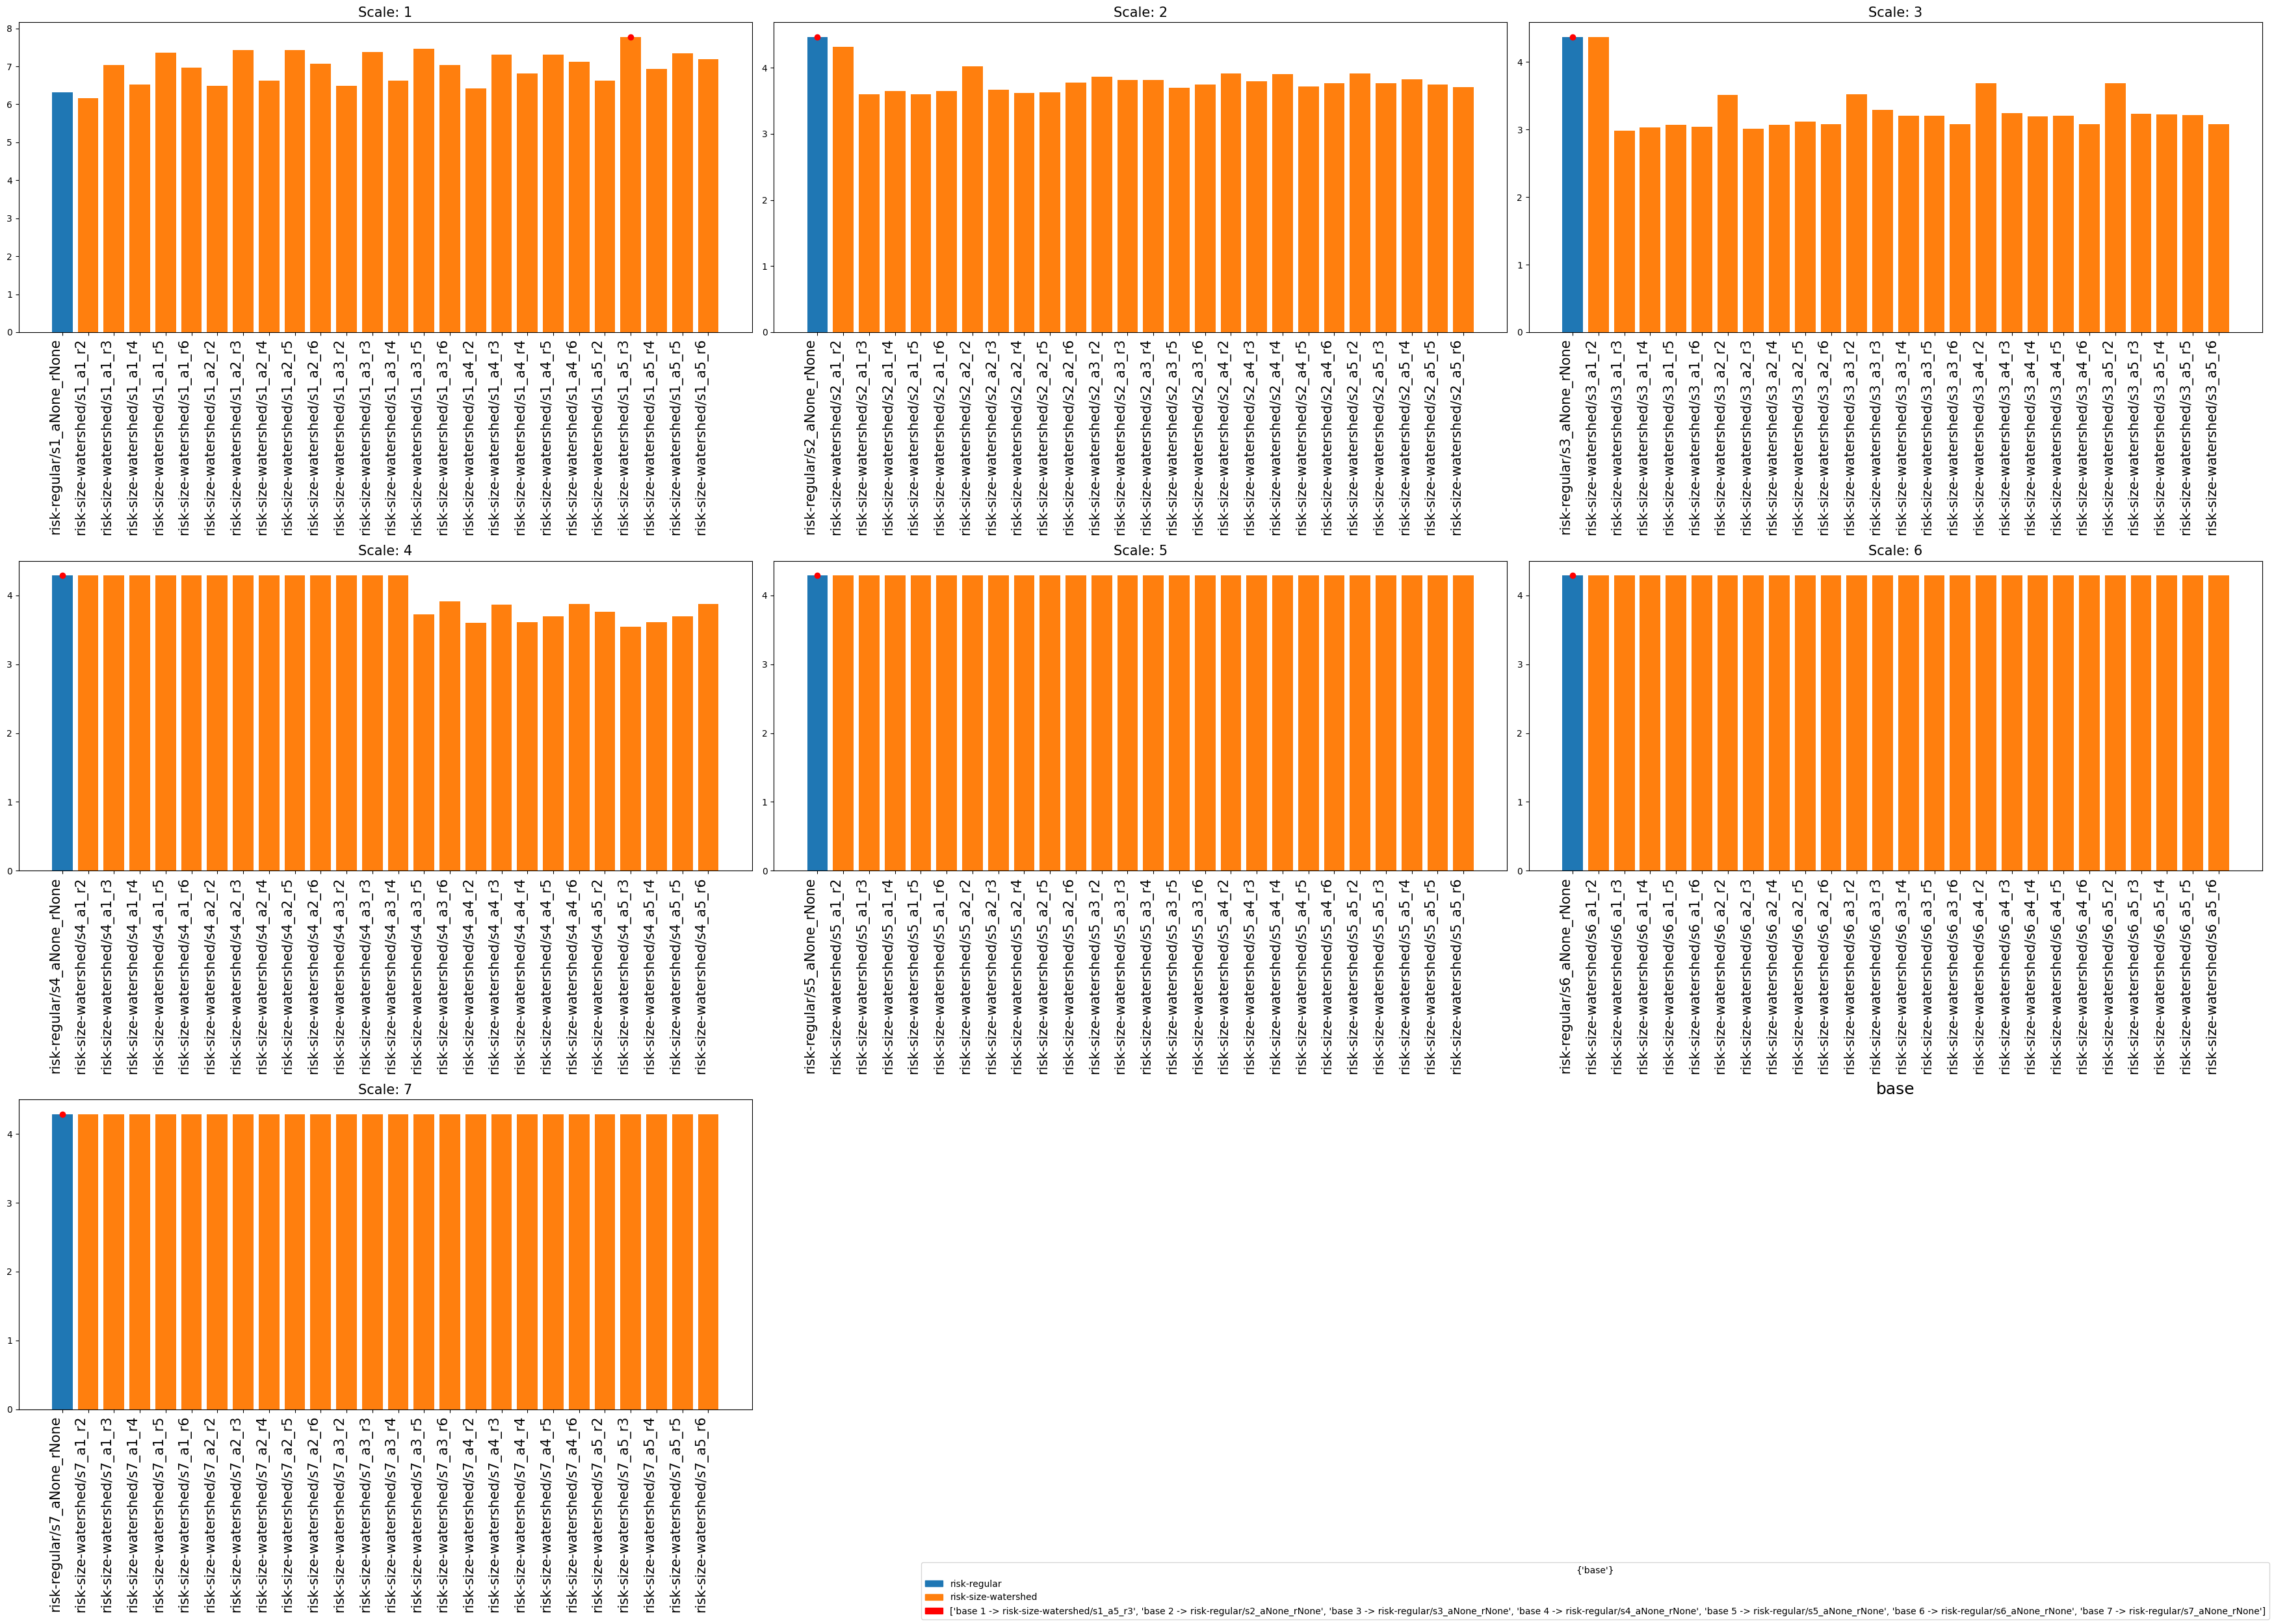

#################### Optimisze parameters #########################
base 1 -> risk-size-watershed/s1_a2_r5
base 2 -> risk-size-watershed/s2_a1_r5
base 3 -> risk-size-watershed/s3_a5_r6
base 4 -> risk-size-watershed/s4_a5_r6
base 5 -> risk-size-watershed/s5_a5_r6
base 6 -> risk-regular/s6_aNone_rNone
base 7 -> risk-regular/s7_aNone_rNone


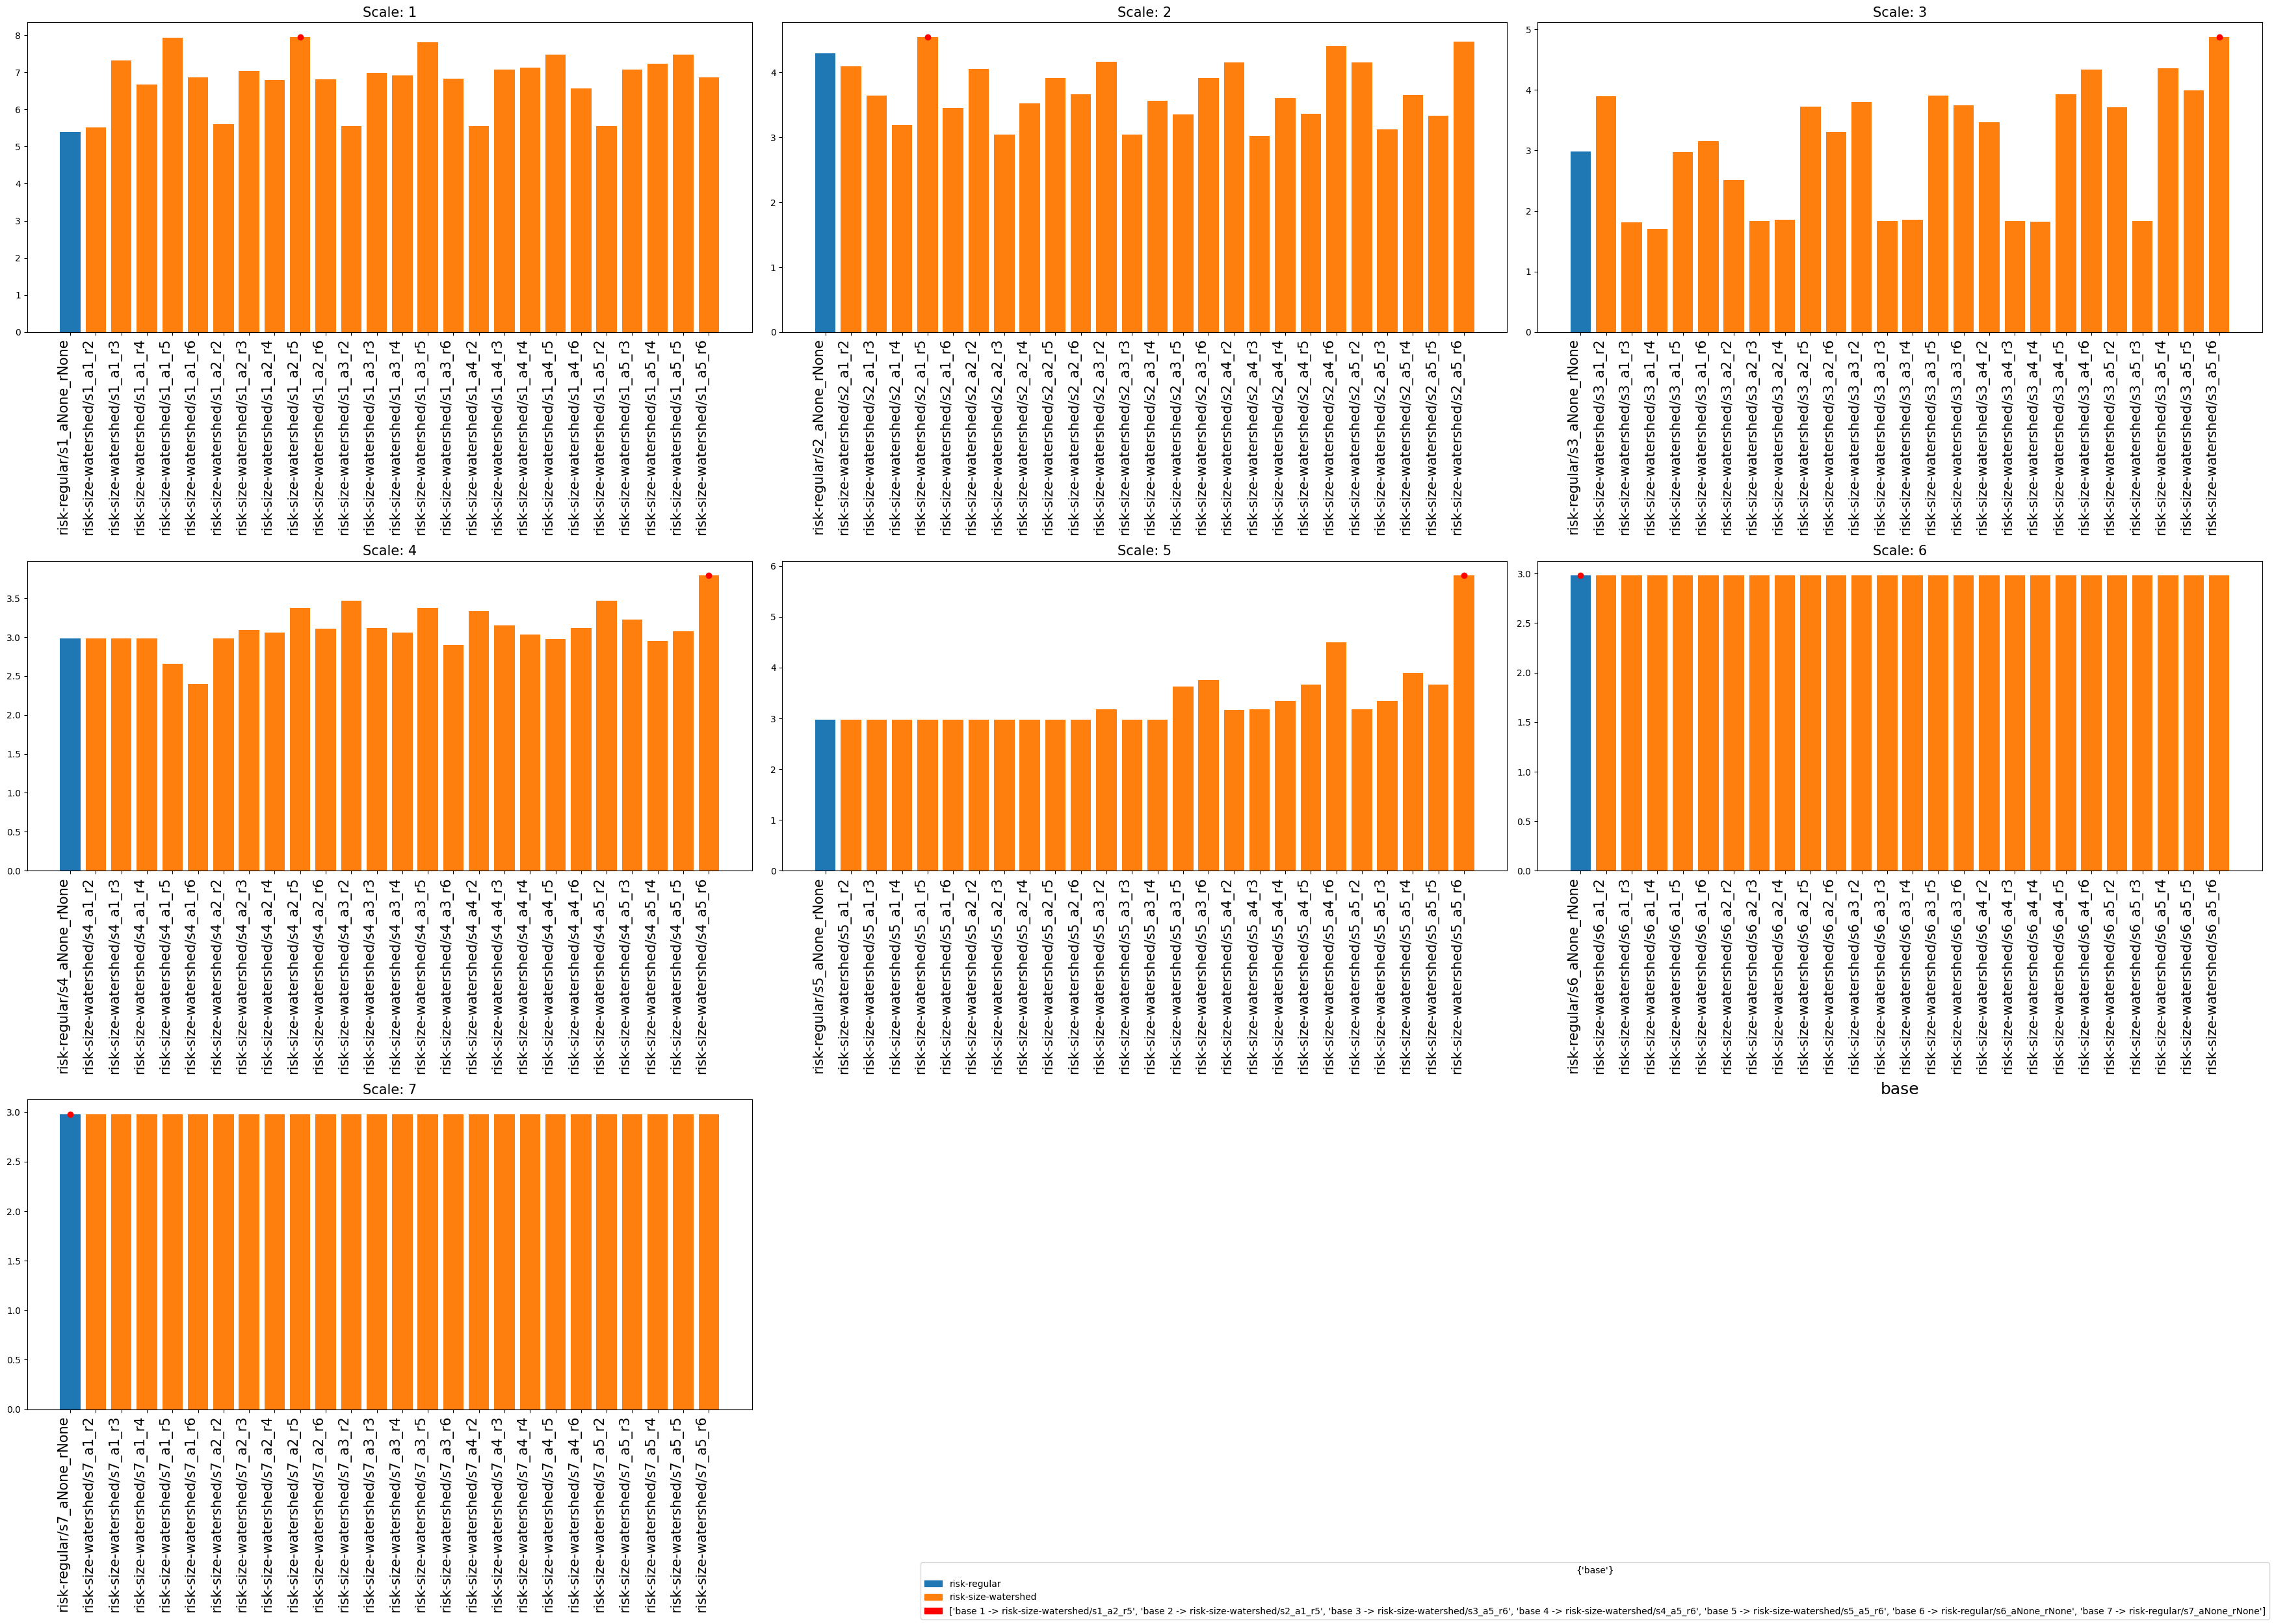

AttributeError: 'NoneType' object has no attribute 'columns'

In [121]:
################# Departement ###################
train_departements = ['departement-01-ain', 'departement-13-bouches-du-rhone', 'departement-25-doubs', 'departement-78-yvelines', 'departement-69-rhone', 'departement-34-hearault']

for dept in train_departements:
    file = Path('/media/caron/X9 Pro/travaille/Thèse/segmentation')
    analyse(file, dept, method)